In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import frustratometer

/home/ezequiel/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/home/ezequiel/anaconda3/lib/python3.11/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


# TEM1 Beta-Lactamase (PDB: 1BLT) Dark Energy Variations


## Folding stability estimation with AWSEM computed with frustratometer

In [2]:
pdb_path = './data/1btl.pdb'
structure=frustratometer.Structure(pdb_path,"A")
AWSEM_model=frustratometer.AWSEM(structure,k_electrostatics=0.0,min_sequence_separation_rho=3, min_sequence_separation_contact=2)

@> 4073 atoms and 1 coordinate set(s) were parsed in 0.03s.
@> 4073 atoms and 1 coordinate set(s) were parsed in 0.03s.


[0.839477 0.937289 0.957784 ... 1.       0.37531  0.86844 ]


In [3]:
FOLD_matrix = AWSEM_model.decoy_fluctuation()[:,1:]*0.05995

## Evolutionary energy with ESM-2 read from data 

In [4]:
def read_large_scale_results_v3(results, 
                                model = 'esm2',
                                reference_alphabet = 'ACDEFGHIKLMNPQRSTVWY',
                                exclude_aa = '-'):
    
    
    if len(exclude_aa)>0:
        for aa in exclude_aa:
            if aa in results.columns:
                results = results.drop(aa,axis=1)
    
    results_matrix = results.values
    alphabet = ''.join(results.columns[:-1])
    sequence = ''.join(results_matrix[:,-1])
    mutational_matrix = results_matrix[:,:-1].astype(float)
   # if model != 'awsem':
        
        
    if alphabet != reference_alphabet:        
        ## this files have a wrong column assingment of alphabet ##
        ALPHABET_map = [alphabet.find(a) for a in reference_alphabet]
        mutational_matrix = mutational_matrix[:,ALPHABET_map]
        alphabet = ''.join(np.array(list(alphabet))[ALPHABET_map])
    seq_index = np.array([alphabet.find(aa) for aa in sequence])     
    if  np.sum(mutational_matrix[np.arange(len(sequence)),seq_index])!=0:   
        ## this files have the raw logits not evo score differences ##
        mutational_matrix-= np.tile(mutational_matrix[np.arange(len(sequence)),seq_index], (len(alphabet),1)).T
    if model != 'awsem':
        mutational_matrix = - mutational_matrix
    return mutational_matrix, sequence, alphabet

In [5]:

EVO_raw = pd.read_csv('data/1btl_A_esm2_t33_650M_UR50D.csv', index_col=0)
EVO_matrix,seq, alphabet = read_large_scale_results_v3(EVO_raw)


## Dark Energy Variations

In [6]:
analysis = frustratometer.DarkEnergy(EVO_matrix,
                          FOLD_matrix,
                          seq,
                          alphabet = alphabet)

In [7]:
pdb_beg = 26
pdb_seq = np.arange(len(seq))+pdb_beg

In [8]:
active_sites = np.array([ 44,  47, 104, 140, 208, 211])+pdb_beg


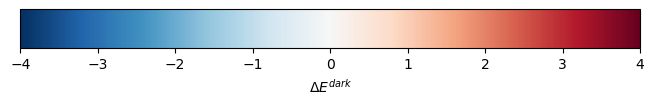

You appear to be running in JupyterLab (or JavaScript failed to load for some other reason). You need to install the 3dmol extension: 
 jupyter labextension install jupyterlab_3dmol

In [9]:
DEM, EVO_r = analysis.compute_dark_energy_matrix(Tsel_from='variance')
aa_freq = analysis.compute_aa_freq(include_gaps=False)
dem_flat = analysis.flat_matrix(DEM, 'pos', aa_freq)

vmax=4.0
pdb_path = './data/1btl.pdb'

analysis.visualize_pdb(pdb_path,  zip_=False, highlight_sites=None, vmax=vmax,pdb_seq_num=pdb_seq,
                      label=r'$\Delta E^{dark}$', highlight_residues=active_sites)


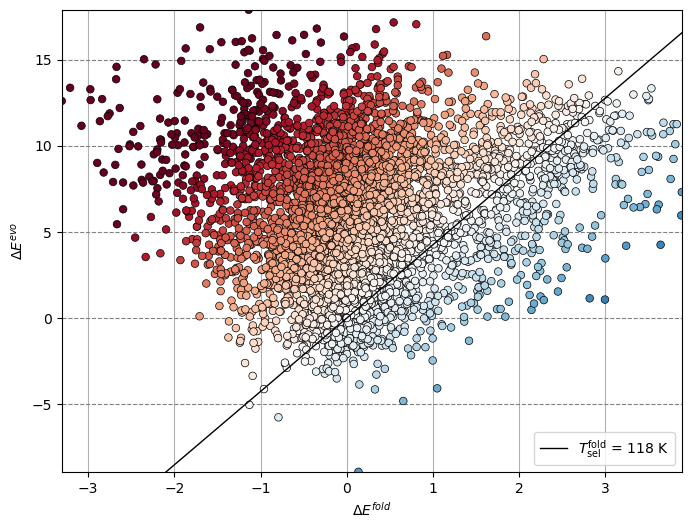

In [10]:
analysis.plot_correlation_color(s=30,lw=.5,alpha=1,vmax=vmax)


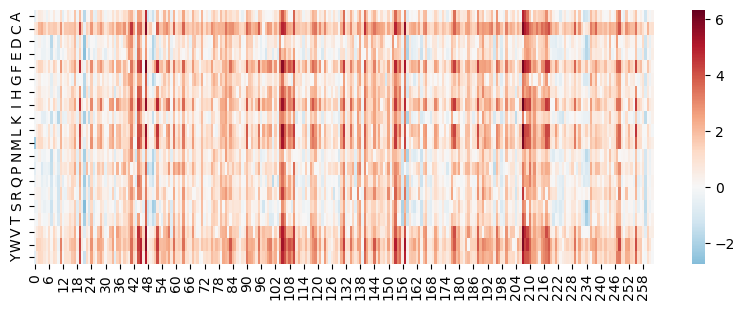

In [11]:
analysis.plot_mutational_matrix() #falta pdb_seq para poner la seq correcta abajo

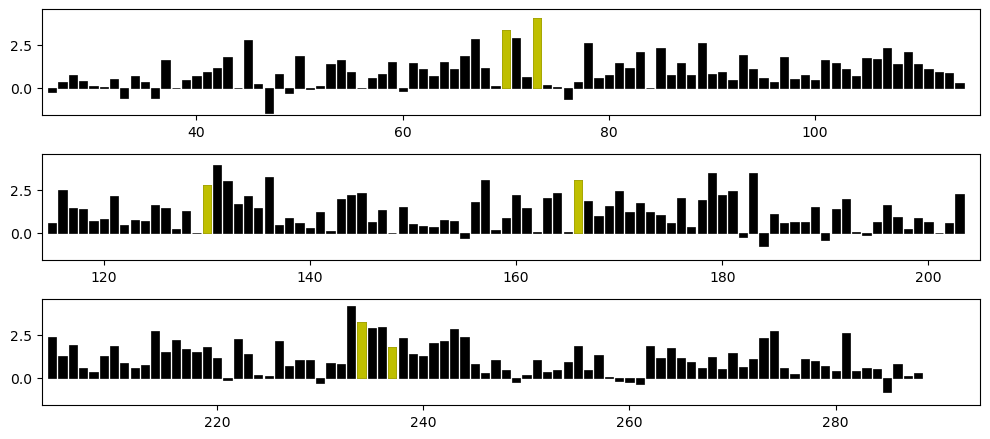

0

In [14]:
analysis.plot_flat_with_highlighted_sites(active_sites = active_sites-pdb_beg, pdb_seq= pdb_seq,
                                          chunk_size = 89)